### 03 - Classification Modeling for High/Low Leptospirosis Risk

 - High : 1
 - Low : 0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    TimeSeriesSplit,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    log_loss,
    average_precision_score,
    precision_recall_curve
)
import optuna
from optuna.samplers import TPESampler
import shap
from sklearn.base import clone
from scipy import stats
import warnings
import joblib

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = "../../data/processed/splitteddataset"

lepto_monthly_train = pd.read_csv(f"{DATA_PATH}/lepto_monthly_train.csv")
lepto_monthly_test = pd.read_csv(f"{DATA_PATH}/lepto_monthly_test.csv")

# Convert District down to a categorical type
lepto_monthly_train["District"] = lepto_monthly_train["District"].astype("category")
lepto_monthly_test["District"] = lepto_monthly_test["District"].astype("category")

print(f"Train raw : {lepto_monthly_train.shape}")
print(f"Test  raw : {lepto_monthly_test.shape}")

Train raw : (3900, 54)
Test  raw : (1200, 54)


In [3]:
lepto_monthly_train.columns

Index(['District', 'Month', 'YearMonth', 'Precipitation_mm', 'Temp_Min_C',
       'Temp_Max_C', 'Soil_Moisture_0_7cm', 'MRiceArea', 'MRiceYield',
       'SRiceArea', 'SRiceYield', 'Population', 'Households', 'mean_temp',
       'BIO2', 'BIO3', 'BIO4', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17',
       'BIO18', 'BIO19', 'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
       'Precipitation_mm_lag3', 'Temp_Min_C_lag1', 'Temp_Min_C_lag2',
       'Temp_Min_C_lag3', 'Temp_Max_C_lag1', 'Temp_Max_C_lag2',
       'Temp_Max_C_lag3', 'Soil_Moisture_0_7cm_lag1',
       'Soil_Moisture_0_7cm_lag2', 'Soil_Moisture_0_7cm_lag3',
       'Precipitation_mm_roll3_mean', 'Precipitation_mm_roll6_mean',
       'Soil_Moisture_0_7cm_roll3_mean', 'Soil_Moisture_0_7cm_roll6_mean',
       'Month_sin', 'Month_cos', 'MRice_x_Precip', 'SRice_x_Precip',
       'Temp_Range', 'Pop_per_Household', 'Precip_vs_norm', 'Precip_anomaly',
       'Waterlog_index', 'Heat_Moisture', 'HR_lag1', 'HR_lag2', 'HR_roll3',
       'Ri


##### ENCODE DISTRICT + REBUILD X_tr/X_test

In [4]:
le = LabelEncoder()
lepto_monthly_train["District_enc"]= le.fit_transform(lepto_monthly_train["District"])
lepto_monthly_test["District_enc"]= le.transform(lepto_monthly_test["District"])

# District-level historical High Risk rate (computed from train only)
district_risk_rate = lepto_monthly_train.groupby("District",observed=False )["RiskLabel"].mean()

lepto_monthly_train["District_risk_rate"] = lepto_monthly_train["District"].map(district_risk_rate).astype(float)
lepto_monthly_test["District_risk_rate"]  = lepto_monthly_test["District"].map(district_risk_rate).astype(float)


# Rebuild X_tr/X_test--includes District_enc + District_risk_rate
drop_cols = ["District", "RiskLabel","YearMonth"]

X_tr   = lepto_monthly_train.drop(columns=drop_cols)
y_tr   = lepto_monthly_train["RiskLabel"]
X_test = lepto_monthly_test.drop(columns=drop_cols)
y_test = lepto_monthly_test["RiskLabel"]


print(f"Final Train : {X_tr.shape} | Class balance: {y_tr.value_counts().to_dict()}")
print(f"Final Test  : {X_test.shape} | Class balance: {y_test.value_counts().to_dict()}")
print(f"District encoded: {sorted(le.classes_)}")

# tscv gap - 1 month buffer = n_districts rows
n_districts = lepto_monthly_train["District"].nunique()
tscv= TimeSeriesSplit(n_splits=5, gap=n_districts)

print(f"\nCorrected tscv gap : {n_districts} rows (1 month buffer)")
print(f"\n{'Fold':<6} {'Train size':<14} {'Val size':<12} {'Val %'}")
print("-" * 45)
for i, (train_idx, val_idx) in enumerate(tscv.split(X_tr, y_tr)):
    print(f"{i+1:<6} {len(train_idx):<14} {len(val_idx):<12} "
          f"{len(val_idx)/len(X_tr)*100:.1f}%")

Final Train : (3900, 53) | Class balance: {0: 2028, 1: 1872}
Final Test  : (1200, 53) | Class balance: {0: 624, 1: 576}
District encoded: ['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Monaragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']

Corrected tscv gap : 25 rows (1 month buffer)

Fold   Train size     Val size     Val %
---------------------------------------------
1      625            650          16.7%
2      1275           650          16.7%
3      1925           650          16.7%
4      2575           650          16.7%
5      3225           650          16.7%



##### OPTUNA - hyperparameter optimization

In [5]:
#####################################################################
# OPTUNA - XGBoost
#####################################################################
def objective_xgb(trial):
    params = {
        "n_estimators":     1000,
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
        "subsample":        trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.1, 5.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1.0, 10.0),
    }

    fold_losses, best_iters = [], []

    for train_idx, val_idx in tscv.split(X_tr, y_tr):
        X_fold_tr,  X_fold_val = X_tr.iloc[train_idx],  X_tr.iloc[val_idx]
        y_fold_tr,  y_fold_val = y_tr.iloc[train_idx],  y_tr.iloc[val_idx]

        model = XGBClassifier(
            objective="binary:logistic", random_state=42,
            tree_method="hist",
            enable_categorical=False,
            early_stopping_rounds=30, eval_metric="logloss",
            **params
        )
        model.fit(X_fold_tr, y_fold_tr,
                  eval_set=[(X_fold_val, y_fold_val)], verbose=False)

        fold_losses.append(log_loss(y_fold_val, model.predict_proba(X_fold_val)[:, 1]))
        best_iters.append(model.best_iteration)

    trial.set_user_attr("avg_best_iter", int(np.mean(best_iters)))
    return np.mean(fold_losses)

#####################################################################
# OPTUNA - LightGBM
#####################################################################

def objective_lgbm(trial):
    params = {
        "n_estimators":      1000,
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 63),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 10.0),
    }

    fold_losses, best_iters = [], []

    for train_idx, val_idx in tscv.split(X_tr, y_tr):
        X_fold_tr,  X_fold_val = X_tr.iloc[train_idx],  X_tr.iloc[val_idx]
        y_fold_tr,  y_fold_val = y_tr.iloc[train_idx],  y_tr.iloc[val_idx]

        model = LGBMClassifier(
            random_state=42, verbose=-1,
            early_stopping_rounds=30,
            **params
        )
        model.fit(X_fold_tr, y_fold_tr,
                  eval_set=[(X_fold_val, y_fold_val)],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(-1)])

        fold_losses.append(log_loss(y_fold_val, model.predict_proba(X_fold_val)[:, 1]))
        best_iters.append(model.best_iteration_)

    trial.set_user_attr("avg_best_iter", int(np.mean(best_iters)))
    return np.mean(fold_losses)

#####################################################################
# OPTUNA - CatBoost
#####################################################################

def objective_cat(trial):
    params = {
        "iterations":        1000,
        "depth":             trial.suggest_int("depth", 3, 7), 
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "subsample":         trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.3, 0.8),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
    }

    fold_losses, best_iters = [], []

    for train_idx, val_idx in tscv.split(X_tr, y_tr):
        X_fold_tr,  X_fold_val = X_tr.iloc[train_idx],  X_tr.iloc[val_idx]
        y_fold_tr,  y_fold_val = y_tr.iloc[train_idx],  y_tr.iloc[val_idx]

        model = CatBoostClassifier(
            random_state=42, verbose=0,
            early_stopping_rounds=30,
            eval_metric="Logloss",
            **params
        )
        model.fit(X_fold_tr, y_fold_tr,
                  eval_set=(X_fold_val, y_fold_val))

        fold_losses.append(log_loss(y_fold_val, model.predict_proba(X_fold_val)[:, 1]))
        best_iters.append(model.best_iteration_)

    trial.set_user_attr("avg_best_iter", int(np.mean(best_iters)))
    return np.mean(fold_losses)


# ===============================================================================
# RUN ABOVE THREE MODELS
# ===============================================================================
studies = {}

for name, objective_fn in [("xgb",  objective_xgb),
                            ("lgbm", objective_lgbm),
                            ("cat",  objective_cat)]:
    print(f"\n{'='*50}\nTuning {name.upper()} ...\n{'='*50}")
    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=40, show_progress_bar=True)
    studies[name] = study
    print(f"{name} - Best Logloss : {study.best_value:.4f}")
    print(f"{name} - Best Params  : {study.best_params}")
    print(f"{name} - Avg best iter: {study.best_trial.user_attrs['avg_best_iter']}")


# ===============================================================================
# BUILD 5 MODELS (Added 2 additional models (RF+Logistic Reg))
# ===============================================================================

all_models = {
 
    # Logistic Regression
    # Pipeline includes StandardScaler - LR is sensitive to feature scale.
    # class_weight="balanced" handles class imbalance automatically.
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ))
    ]),
 
    # Random Forest (structurally diverse from boosters)
    "rf": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
 
    # Tuned gradient boosters
    "xgb": XGBClassifier(
        objective="binary:logistic",
        random_state=42,
        tree_method="hist",
        enable_categorical=False,
        n_estimators=studies["xgb"].best_trial.user_attrs["avg_best_iter"],
        **studies["xgb"].best_params,
    ),
 
    "lgbm": LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_estimators=studies["lgbm"].best_trial.user_attrs["avg_best_iter"],
        **studies["lgbm"].best_params,
    ),
 
    "cat": CatBoostClassifier(
        random_state=42,
        verbose=0,
        iterations=studies["cat"].best_trial.user_attrs["avg_best_iter"],
        **studies["cat"].best_params,
    ),
}
 


Tuning XGB ...


  0%|          | 0/40 [00:00<?, ?it/s]

xgb - Best Logloss : 0.5269
xgb - Best Params  : {'max_depth': 3, 'learning_rate': 0.022181068029381235, 'gamma': 0.23736267699800004, 'subsample': 0.6174579338862809, 'colsample_bytree': 0.32608903518711396, 'min_child_weight': 10, 'reg_alpha': 4.447751485430664, 'reg_lambda': 3.809731107914759}
xgb - Avg best iter: 257

Tuning LGBM ...


  0%|          | 0/40 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's binary_logloss: 0.772715
Training until validation scores don't improve for 30 rounds
Training until validation scores don't improve for 30 rounds


...

Early stopping, best iteration is:
[286]	valid_0's binary_logloss: 0.463432
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[14]	valid_0's binary_logloss: 0.77936
Training until validation scores don't improve for 30 rounds
Training until validation scores don't improve for 30 rounds


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[148]	valid_0's binary_logloss: 0.559399
Training until validation scores don't improve for 30 rounds


lgbm - Best Logloss : 0.5381
lgbm - Best Params  : {'max_depth': 3, 'num_leaves': 34, 'learning_rate': 0.01901465737350211, 'subsample': 0.7071269550661432, 'colsample_bytree': 0.39122765614973304, 'min_child_samples': 20, 'reg_alpha': 4.37050170998428, 'reg_lambda': 3.63786484975193}
lgbm - Avg best iter: 262

Tuning CAT ...


  0%|          | 0/40 [00:00<?, ?it/s]

cat - Best Logloss : 0.4968
cat - Best Params  : {'depth': 4, 'learning_rate': 0.050193102949832674, 'l2_leaf_reg': 8.133778989170452, 'subsample': 0.7212663057499048, 'colsample_bylevel': 0.3852471589608517, 'min_data_in_leaf': 35}
cat - Avg best iter: 75



##### Fit all models on full training data and collect test probabilities.

In [6]:
print("\n" + "="*60)
print("FITTING ALL MODELS ON FULL TRAINING DATA")
print("="*60)
 
all_test_probs = {}
 
for name, model in all_models.items():
    print(f"  Fitting {name} ...", end=" ")
 
    if name == "logreg":
        # Pipeline - fit directly
        model.fit(X_tr, y_tr)
 
    elif name == "rf":
        model.fit(X_tr, y_tr)
 
    elif name == "xgb":
        model.fit(X_tr, y_tr)
 
    elif name == "lgbm":
        # LightGBM: n_estimators set from Optuna avg_best_iter,
        # fitting on full data-no early stopping
        model.set_params(n_estimators=studies["lgbm"].best_trial.user_attrs["avg_best_iter"])
        model.fit(X_tr, y_tr)
 
    elif name == "cat":
        model.fit(X_tr, y_tr)
 
    probs = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, probs)
    all_test_probs[name] = probs
    print(f"Test AUC = {auc:.4f}")
 


FITTING ALL MODELS ON FULL TRAINING DATA
  Fitting logreg ... Test AUC = 0.8904
  Fitting rf ... 

Test AUC = 0.8990
  Fitting xgb ... 

Test AUC = 0.8948
  Fitting lgbm ... Test AUC = 0.8945
  Fitting cat ... 

Test AUC = 0.8919



##### SELECT FINAL MODEL
 - Best model is determined by test AUC across all 5 candidates.
 - In case of a tie (AUC difference < 0.001), prefer the simpler model.

In [7]:
best_name  = max(all_test_probs, key=lambda n: roc_auc_score(y_test, all_test_probs[n]))
final_probs = all_test_probs[best_name]
final_model = all_models[best_name]
 
print(f"\n  Best model : {best_name}  "
      f"(AUC = {roc_auc_score(y_test, final_probs):.4f})")
print(f"  This model is used for all subsequent evaluation sections.\n")
 


  Best model : rf  (AUC = 0.8990)
  This model is used for all subsequent evaluation sections.




##### EVALUATION

**Helper Functions**

_Cost-ratio threshold_

In [8]:
# Optimal Bayes threshold = cost_fp / (cost_fp + cost_fn)
THRESHOLD = 0.45
final_preds = (final_probs >= THRESHOLD).astype(int)
 
print(f"Decision threshold : {THRESHOLD:.2f}  ")
print(f"Final model AUC    : {roc_auc_score(y_test, final_probs):.4f}")
print(f"Prevalence (test)  : {y_test.mean():.3f}\n")
 

Decision threshold : 0.45  
Final model AUC    : 0.8990
Prevalence (test)  : 0.480



_DeLong test helper_

In [9]:

def delong_test(y_true, prob_a, prob_b):
    """Two-sided DeLong test: H0: AUC(prob_a) == AUC(prob_b)
    Returns z, p-value, auc_a, auc_b.  prob_a is the stronger model."""
    ### If p value is <=0.05 reject H0
    y_true = np.asarray(y_true)
    prob_a = np.asarray(prob_a)
    prob_b = np.asarray(prob_b)
    pos, neg = y_true == 1, y_true == 0
    n_pos, n_neg = pos.sum(), neg.sum()
 
    def _place(p):
        pp, np_ = p[pos], p[neg]
        v10 = np.array([(x > np_).mean() + 0.5*(x == np_).mean() for x in pp])
        v01 = np.array([(x < pp).mean()  + 0.5*(x == pp).mean()  for x in np_])
        return v10, v01
 
    v10a, v01a = _place(prob_a)
    v10b, v01b = _place(prob_b)
    s10 = np.cov(v10a, v10b, ddof=1)
    s01 = np.cov(v01a, v01b, ddof=1)
    var = (s10[0,0]/n_pos + s01[0,0]/n_neg
         + s10[1,1]/n_pos + s01[1,1]/n_neg
         - 2*(s10[0,1] + s01[0,1]) / np.sqrt(n_pos * n_neg))
    if var <= 0:
        var = (np.var(v10a, ddof=1)/n_pos + np.var(v01a, ddof=1)/n_neg
             + np.var(v10b, ddof=1)/n_pos + np.var(v01b, ddof=1)/n_neg)
    auc_a = roc_auc_score(y_true, prob_a)
    auc_b = roc_auc_score(y_true, prob_b)
    z = (auc_a - auc_b) / np.sqrt(max(var, 1e-12))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b

##### SECTION 1 - ROC-AUC + PRECISION-RECALL CURVES  (all 5 models + final)

SECTION 1 - ROC-AUC & PRECISION-RECALL CURVES


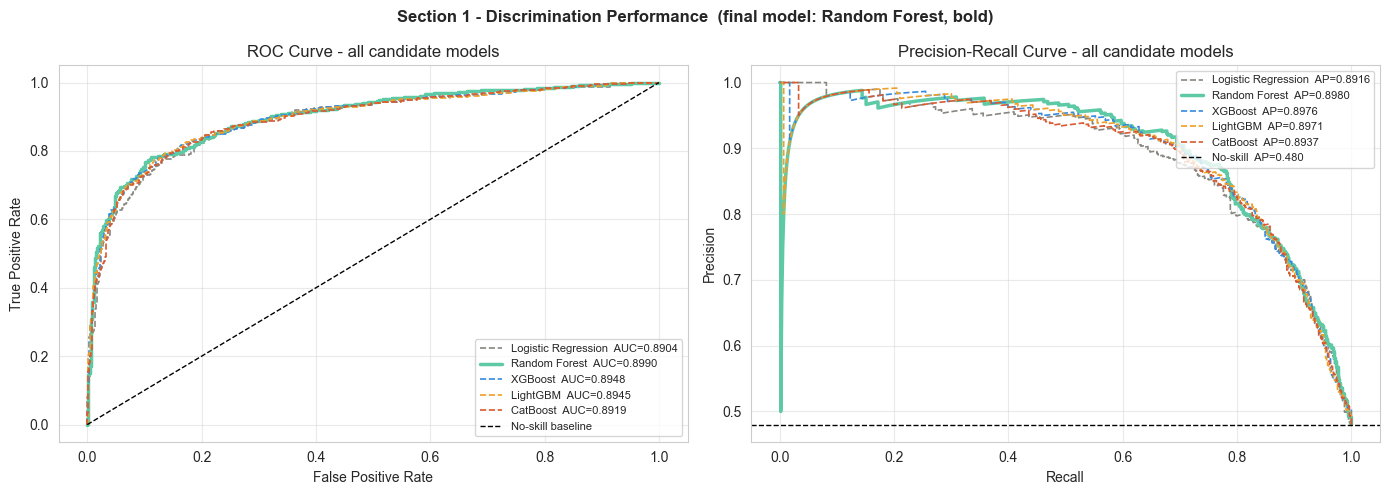


  Model                       AUC        AP
  ------------------------------------------
  Logistic Regression      0.8904    0.8916
  Random Forest            0.8990    0.8980  <-final
  XGBoost                  0.8948    0.8976
  LightGBM                 0.8945    0.8971
  CatBoost                 0.8919    0.8937


In [10]:
print("="*60)
print("SECTION 1 - ROC-AUC & PRECISION-RECALL CURVES")
print("="*60)
 
# Colour palette - one colour per model
MODEL_COLORS = {
    "logreg" : "#888780",
    "rf"     : "#5DCAA5",
    "xgb"    : "#378ADD",
    "lgbm"   : "#EF9F27",
    "cat"    : "#D85A30",
}
MODEL_LABELS = {
    "logreg" : "Logistic Regression",
    "rf"     : "Random Forest",
    "xgb"    : "XGBoost",
    "lgbm"   : "LightGBM",
    "cat"    : "CatBoost",
}

 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_ap = y_test.mean()
 
for name, probs in all_test_probs.items():
    auc  = roc_auc_score(y_test, probs)
    ap   = average_precision_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    pre, rec, _ = precision_recall_curve(y_test, probs)
    lw   = 2.5 if name == best_name else 1.2
    ls   = "-"  if name == best_name else "--"
    col  = MODEL_COLORS[name]
    axes[0].plot(fpr, tpr, color=col, lw=lw, ls=ls,
                 label=f"{MODEL_LABELS[name]}  AUC={auc:.4f}")
    axes[1].plot(rec, pre, color=col, lw=lw, ls=ls,
                 label=f"{MODEL_LABELS[name]}  AP={ap:.4f}")
 
axes[0].plot([0,1],[0,1],"k--",lw=1,label="No-skill baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - all candidate models")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.4)
 
axes[1].axhline(y=baseline_ap, color="k", linestyle="--", lw=1,
                label=f"No-skill  AP={baseline_ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve - all candidate models")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.4)
 
plt.suptitle(f"Section 1 - Discrimination Performance  "
             f"(final model: {MODEL_LABELS[best_name]}, bold)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig1_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\n  {'Model':<22} {'AUC':>8}  {'AP':>8}")
print("  " + "-"*42)
for name, probs in all_test_probs.items():
    marker = "  <-final" if name == best_name else ""
    print(f"  {MODEL_LABELS[name]:<22} "
          f"{roc_auc_score(y_test, probs):>8.4f}  "
          f"{average_precision_score(y_test, probs):>8.4f}{marker}")

##### SECTION 2 - MODEL COMPARISON TABLE


SECTION 2 - MODEL COMPARISON TABLE

  Model                       AUC   ΔAUC vs best
  ----------------------------------------------
  Logistic Regression      0.8904        -0.0087
  Random Forest            0.8990        +0.0000  <- selected
  XGBoost                  0.8948        -0.0042
  LightGBM                 0.8945        -0.0045
  CatBoost                 0.8919        -0.0071


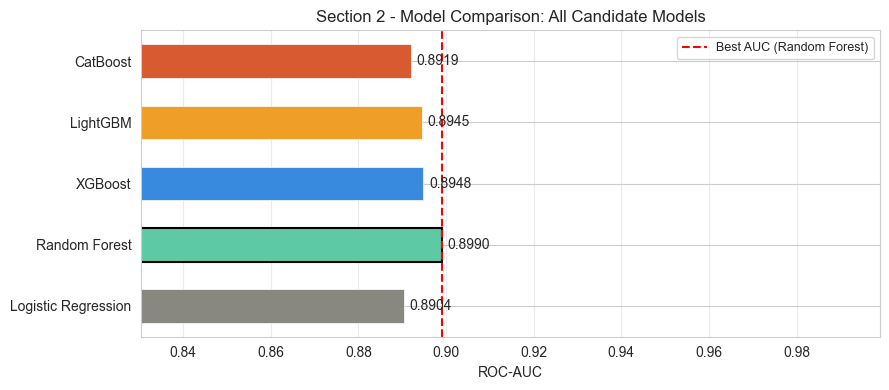


  Note: Random Forest selected as final model (highest AUC).
  All subsequent sections report results for Random Forest only.


In [11]:

print("\n" + "="*60)
print("SECTION 2 - MODEL COMPARISON TABLE")
print("="*60)
 
model_aucs  = {n: roc_auc_score(y_test, p) for n, p in all_test_probs.items()}
best_auc    = model_aucs[best_name]
 
print(f"\n  {'Model':<22} {'AUC':>8}  {'ΔAUC vs best':>13}")
print("  " + "-"*46)
for name in all_test_probs:
    delta  = model_aucs[name] - best_auc
    marker = "  <- selected" if name == best_name else ""
    print(f"  {MODEL_LABELS[name]:<22} {model_aucs[name]:>8.4f}  "
          f"{delta:>+13.4f}{marker}")
 
# Horizontal bar chart
names_plot  = list(all_test_probs.keys())
aucs_plot   = [model_aucs[n] for n in names_plot]
labels_plot = [MODEL_LABELS[n] for n in names_plot]
colors_plot = [MODEL_COLORS[n] for n in names_plot]
edge_plot   = ["black" if n == best_name else "white" for n in names_plot]
lw_plot     = [1.5 if n == best_name else 0.5 for n in names_plot]
 
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels_plot, aucs_plot, color=colors_plot,
               edgecolor=edge_plot, linewidth=lw_plot, height=0.55)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.axvline(x=best_auc, color="red", linestyle="--", lw=1.5,
           label=f"Best AUC ({MODEL_LABELS[best_name]})")
ax.set_xlabel("ROC-AUC")
ax.set_title("Section 2 - Model Comparison: All Candidate Models")
x_min = min(aucs_plot) - 0.06
ax.set_xlim(x_min, best_auc + 0.10)
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Note: {MODEL_LABELS[best_name]} selected as final model (highest AUC).")
print(f"  All subsequent sections report results for {MODEL_LABELS[best_name]} only.")

##### SECTION 3 - DeLong SIGNIFICANCE TEST

 - Final model vs every other candidate on the same test set.


SECTION 3 - DeLong SIGNIFICANCE TEST

  H0: AUC(Random Forest) = AUC(other model)  [two-sided, DeLong 1988]

  Model                   Other AUC   Best AUC     ΔAUC        z          p       
  ──────────────────────────────────────────────────────────────────────────
  Logistic Regression        0.8904     0.8990  +0.0087    2.087     0.0369      *
  XGBoost                    0.8948     0.8990  +0.0042    1.359     0.1741   n.s.
  LightGBM                   0.8945     0.8990  +0.0045    1.403     0.1605   n.s.
  CatBoost                   0.8919     0.8990  +0.0071    2.020     0.0433      *

  * p<0.05   ** p<0.01   *** p<0.001

  Interpretation guide:
   Significant + positive ΔAUC --> final model is genuinely better.
   Non-significant ΔAUC        --> models are statistically equivalent;
                                  selection is based on point estimate only.


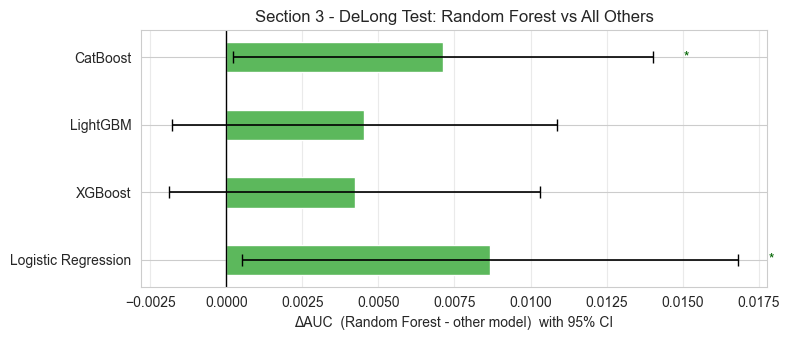

In [12]:

print("\n" + "="*60)
print("SECTION 3 - DeLong SIGNIFICANCE TEST")
print("="*60)
print(f"\n  H0: AUC({MODEL_LABELS[best_name]}) = AUC(other model)  "
      f"[two-sided, DeLong 1988]")
 
print(f"\n  {'Model':<22} {'Other AUC':>10}  {'Best AUC':>9}  "
      f"{'ΔAUC':>7}  {'z':>7}  {'p':>9}  {'':>5}")
print("  " + "─"*74)
 
delong_results = {}
for name, probs in all_test_probs.items():
    if name == best_name:
        continue
    z, p, auc_best, auc_other = delong_test(y_test, final_probs, probs)
    delta = auc_best - auc_other
    sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    delong_results[name] = dict(auc=auc_other, z=z, p=p, delta=delta, sig=sig)
    print(f"  {MODEL_LABELS[name]:<22} {auc_other:>10.4f}  {auc_best:>9.4f}  "
          f"{delta:>+7.4f}  {z:>7.3f}  {p:>9.4f}  {sig:>5}")
 
print("\n  * p<0.05   ** p<0.01   *** p<0.001")
print("\n  Interpretation guide:")
print("   Significant + positive ΔAUC --> final model is genuinely better.")
print("   Non-significant ΔAUC        --> models are statistically equivalent;")
print("                                  selection is based on point estimate only.")

# Forest-style ΔAUC plot
fig, ax = plt.subplots(figsize=(8, 3.5))
names_d  = list(delong_results.keys())
deltas_d = [delong_results[n]["delta"] for n in names_d]
ci_d     = [abs(delong_results[n]["delta"]) /
            max(abs(delong_results[n]["z"]), 1e-6) * 1.96
            for n in names_d]
labels_d = [MODEL_LABELS[n] for n in names_d]
colors_d = ["#5cb85c" if d > 0 else "#d9534f" for d in deltas_d]
 
y_pos = np.arange(len(names_d))
ax.barh(y_pos, deltas_d, xerr=ci_d, color=colors_d,
        height=0.45, capsize=4,
        error_kw={"elinewidth": 1.2})
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(labels_d)
ax.set_xlabel(f"ΔAUC  ({MODEL_LABELS[best_name]} - other model)  with 95% CI")
ax.set_title(f"Section 3 - DeLong Test: {MODEL_LABELS[best_name]} vs All Others")
ax.grid(axis="x", alpha=0.4)
for i, n in enumerate(names_d):
    sig = delong_results[n]["sig"]
    if sig != "n.s.":
        ax.text(deltas_d[i] + ci_d[i] + 0.001, i, sig,
                va="center", fontsize=10, color="darkgreen")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig3_delong.png", dpi=150, bbox_inches="tight")
plt.show()
 

##### SECTION 4 - CONFUSION MATRIX + CLASSIFICATION REPORT  (final model only)


SECTION 4 - CONFUSION MATRIX & CLASSIFICATION REPORT

  Model     : Random Forest
  Threshold : 0.45  


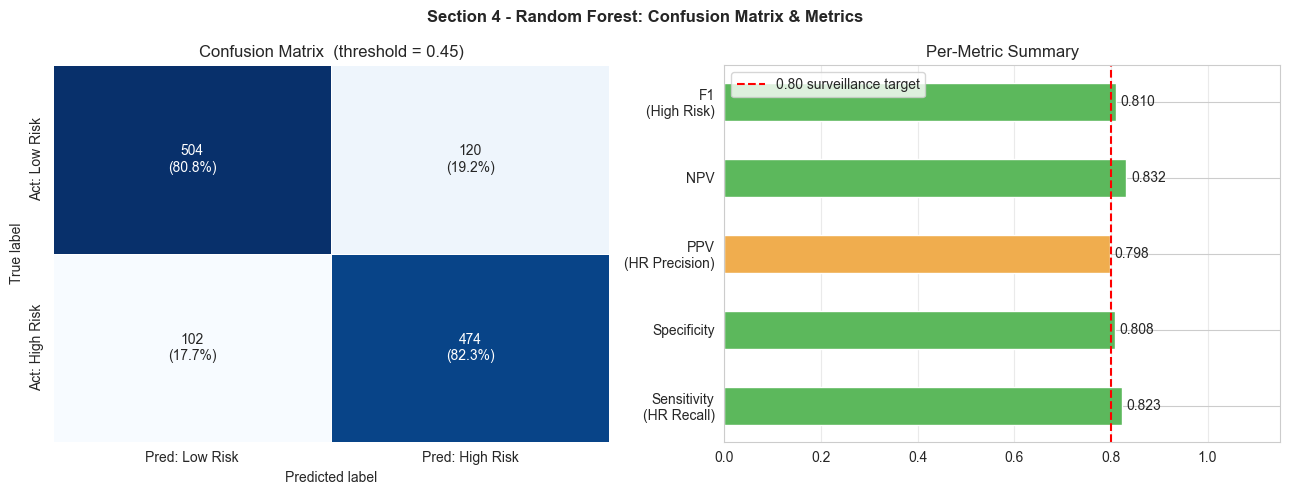


  TP=474  FP=120  FN=102  TN=504
  Sensitivity (HR Recall) : 0.8229  High sensitivity
  Specificity             : 0.8077
  PPV (HR Precision)      : 0.7980
  NPV                     : 0.8317
  F1 (High Risk)          : 0.8103

              precision    recall  f1-score   support

    Low Risk       0.83      0.81      0.82       624
   High Risk       0.80      0.82      0.81       576

    accuracy                           0.81      1200
   macro avg       0.81      0.82      0.81      1200
weighted avg       0.82      0.81      0.82      1200



In [13]:

print("\n" + "="*60)
print("SECTION 4 - CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*60)
print(f"\n  Model     : {MODEL_LABELS[best_name]}")
print(f"  Threshold : {THRESHOLD:.2f}  ")
 
cm = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = cm.ravel()
 
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp + 1e-9)
npv         = tn / (tn + fn + 1e-9)
f1_hr       = 2 * ppv * sensitivity / (ppv + sensitivity + 1e-9)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Heatmap with counts + row percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                   for row_v, row_p in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=axes[0],
            xticklabels=["Pred: Low Risk", "Pred: High Risk"],
            yticklabels=["Act: Low Risk",  "Act: High Risk"],
            linewidths=0.5, linecolor="white", cbar=False)
axes[0].set_title(f"Confusion Matrix  (threshold = {THRESHOLD:.2f})")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
 
# Metrics bar chart
metric_names  = ["Sensitivity\n(HR Recall)", "Specificity",
                 "PPV\n(HR Precision)", "NPV", "F1\n(High Risk)"]
metric_values = [sensitivity, specificity, ppv, npv, f1_hr]
bar_c = ["#d9534f" if v < 0.70 else "#f0ad4e" if v < 0.80 else "#5cb85c"
         for v in metric_values]
axes[1].barh(metric_names, metric_values, color=bar_c,
             edgecolor="white", height=0.5)
for i, v in enumerate(metric_values):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
axes[1].axvline(0.80, color="red", linestyle="--", lw=1.5,
                label="0.80 surveillance target")
axes[1].set_xlim(0, 1.15)
axes[1].set_title("Per-Metric Summary")
axes[1].legend(); axes[1].grid(axis="x", alpha=0.4)
 
plt.suptitle(f"Section 4 - {MODEL_LABELS[best_name]}: Confusion Matrix & Metrics",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig4_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\n  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Sensitivity (HR Recall) : {sensitivity:.4f}"
      f"{'  High sensitivity' if sensitivity >= 0.80 else '  below 0.80 - consider raising COST_FN'}")
print(f"  Specificity             : {specificity:.4f}")
print(f"  PPV (HR Precision)      : {ppv:.4f}")
print(f"  NPV                     : {npv:.4f}")
print(f"  F1 (High Risk)          : {f1_hr:.4f}")
print()
print(classification_report(y_test, final_preds,
                             target_names=["Low Risk", "High Risk"]))



##### SECTION 5 - DISTRICT-LEVEL RECALL  (final model only)

SECTION 5 - DISTRICT-LEVEL PERFORMANCE


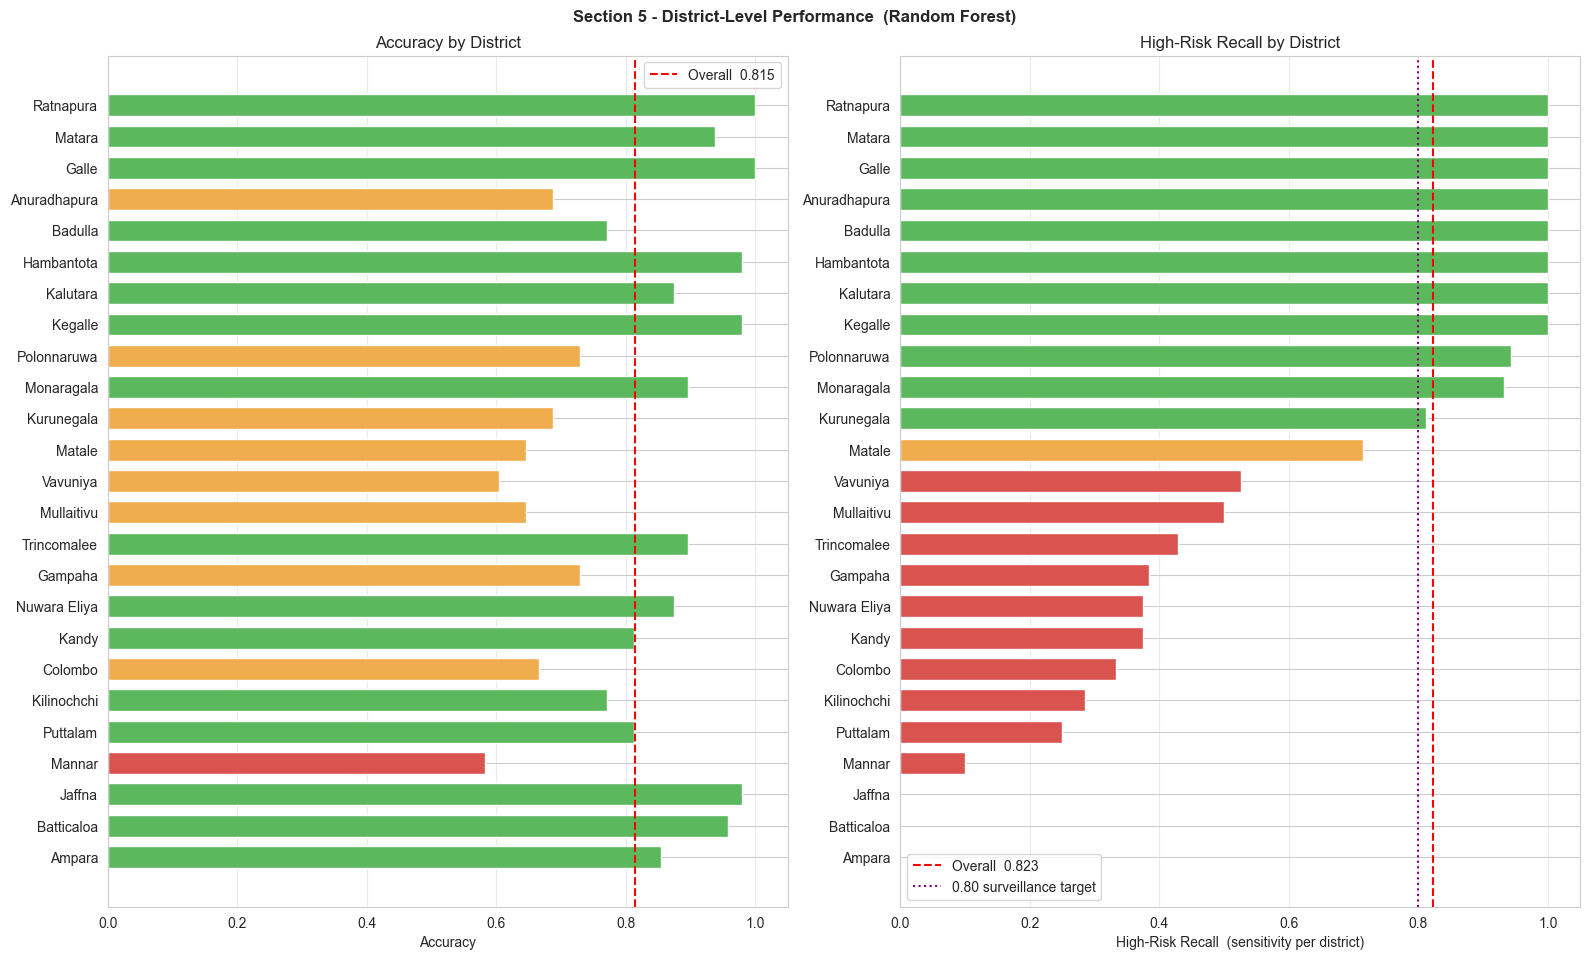


  District              Accuracy  HR Recall   HR Rate      N
  ──────────────────────────────────────────────────────────
  Ampara                   0.854      0.000     0.146     48  🔴
  Batticaloa               0.958      0.000     0.042     48  🔴
  Jaffna                   0.979      0.000     0.021     48  🔴
  Mannar                   0.583      0.100     0.417     48  🔴
  Puttalam                 0.812      0.250     0.167     48  🔴
  Kilinochchi              0.771      0.286     0.292     48  🔴
  Colombo                  0.667      0.333     0.125     48  🔴
  Kandy                    0.812      0.375     0.167     48  🔴
  Nuwara Eliya             0.875      0.375     0.167     48  🔴
  Gampaha                  0.729      0.385     0.271     48  🔴
  Trincomalee              0.896      0.429     0.146     48  🔴
  Mullaitivu               0.646      0.500     0.458     48  🔴
  Vavuniya                 0.604      0.526     0.396     48  🔴
  Matale                   0.646      0.714  

In [14]:
print("="*60)
print("SECTION 5 - DISTRICT-LEVEL PERFORMANCE")
print("="*60)
 
test_eval = (lepto_monthly_test[["District"]]
             .copy().reset_index(drop=True))
test_eval["y_true"]  = y_test.values
test_eval["y_pred"]  = final_preds
test_eval["y_prob"]  = final_probs
test_eval["correct"] = (test_eval["y_true"] == test_eval["y_pred"]).astype(int)
 
district_stats = (
    test_eval
    .groupby("District")
    .apply(lambda g: pd.Series({
        "Accuracy"  : (g["y_true"] == g["y_pred"]).mean(),
        "HR_Recall" : (((g["y_pred"]==1) & (g["y_true"]==1)).sum()
                       / max((g["y_true"]==1).sum(), 1)),
        "HR_Rate"   : g["y_true"].mean(),
        "N"         : len(g),
    }))
    .reset_index()
    .sort_values("HR_Recall")
)
 
overall_acc    = (final_preds == y_test).mean()
overall_recall = sensitivity
 
fig, axes = plt.subplots(1, 2,
    figsize=(16, max(5, len(district_stats) * 0.35 + 1)))
 
acc_colors = ["#d9534f" if a < 0.60 else "#f0ad4e" if a < 0.75 else "#5cb85c"
              for a in district_stats["Accuracy"]]
axes[0].barh(district_stats["District"].astype(str),
             district_stats["Accuracy"],
             color=acc_colors, edgecolor="white", height=0.7)
axes[0].axvline(x=overall_acc, color="red", linestyle="--", lw=1.5,
                label=f"Overall  {overall_acc:.3f}")
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy by District")
axes[0].legend(); axes[0].grid(axis="x", alpha=0.4)
 
recall_colors = ["#d9534f" if r < 0.60 else "#f0ad4e" if r < 0.80 else "#5cb85c"
                 for r in district_stats["HR_Recall"]]
axes[1].barh(district_stats["District"].astype(str),
             district_stats["HR_Recall"],
             color=recall_colors, edgecolor="white", height=0.7)
axes[1].axvline(x=overall_recall, color="red", linestyle="--", lw=1.5,
                label=f"Overall  {overall_recall:.3f}")
axes[1].axvline(x=0.80, color="purple", linestyle=":", lw=1.5,
                label="0.80 surveillance target")
axes[1].set_xlabel("High-Risk Recall  (sensitivity per district)")
axes[1].set_title("High-Risk Recall by District")
axes[1].legend(); axes[1].grid(axis="x", alpha=0.4)
 
plt.suptitle(f"Section 5 - District-Level Performance  "
             f"({MODEL_LABELS[best_name]})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig5_district.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\n  {'District':<20} {'Accuracy':>9}  {'HR Recall':>9}  "
      f"{'HR Rate':>8}  {'N':>5}")
print("  " + "─"*58)
for _, row in district_stats.iterrows():
    flag = "  🔴" if row["HR_Recall"] < 0.60 else ""
    print(f"  {str(row['District']):<20} {row['Accuracy']:>9.3f}  "
          f"{row['HR_Recall']:>9.3f}  {row['HR_Rate']:>8.3f}  "
          f"{int(row['N']):>5}{flag}")
 
print(f"\n  Worst 5 districts by HR Recall")

#### **RESULTS SUMMARY TABLE**

##### SECTION 7 - OVERFITTING / UNDERFITTING CHECK

SECTION 7 - OVERFITTING / UNDERFITTING CHECK



  CV AUC  (mean ± std) : 0.8066 ± 0.1096
  Test AUC             : 0.8990
  Gap (test - CV)      : +0.0924
  Verdict : large gap - investigate fold distribution below


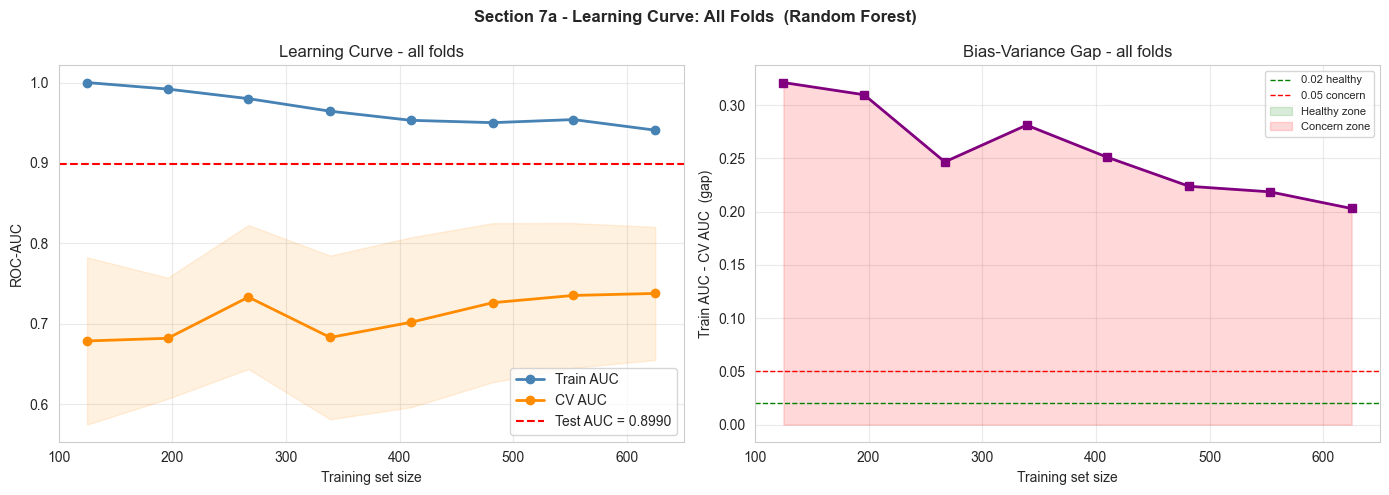


Class distribution across folds:
  Fold    Train HR    Val HR   |HR gap|       AUC  Status
  ────────────────────────────────────────────────────────────────────
  1          0.296     0.588      0.292    0.6183  EXCLUDE - |HR gap| 0.292 > 0.1
  2          0.461     0.549      0.088    0.9567  reliable
  3          0.490     0.488      0.003    0.8056  reliable
  4          0.482     0.482      0.000    0.8005  reliable
  5          0.483     0.457      0.026    0.8520  reliable

  Folds excluded (|HR gap| > 0.1) : 1
  Folds retained                       : 4


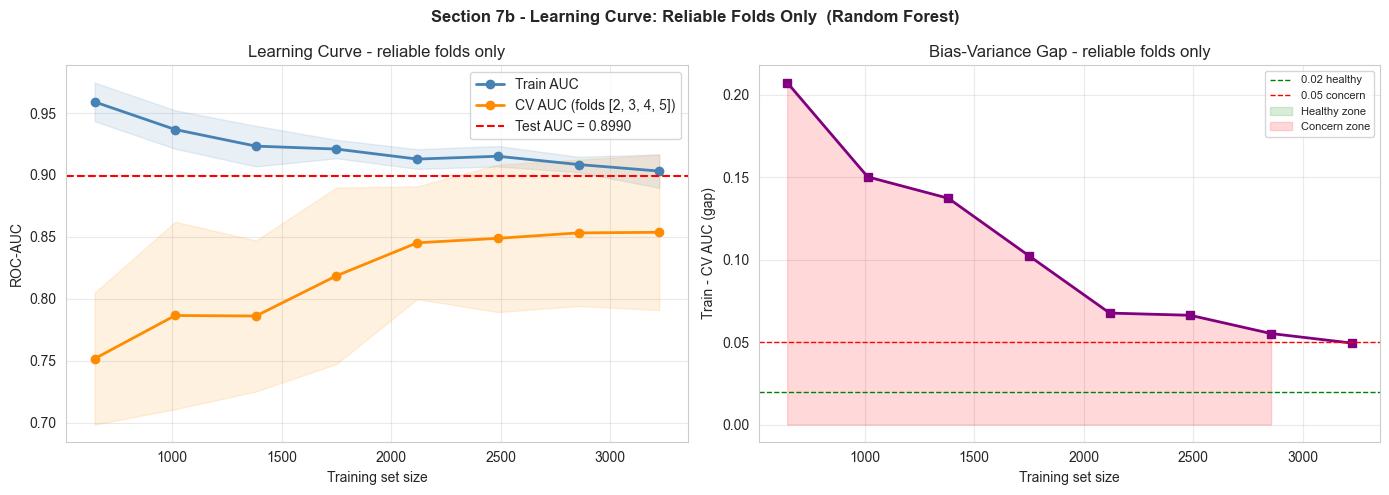


  Reliable CV AUC (matched prevalence) : 0.8537 ± 0.0627
  Test AUC                             : 0.8990
  Gap (test - reliable CV)             : +0.0454

  Verdict : mild variance - acceptable


In [15]:
print("="*60)
print("SECTION 7 - OVERFITTING / UNDERFITTING CHECK")
print("="*60)

# Check 1: per-fold CV AUC (cross validation auc)
cv_fold_aucs = []
for train_idx, val_idx in tscv.split(X_tr, y_tr):
    m_cv = CatBoostClassifier(
        random_state=42, verbose=0,
        iterations=studies["cat"].best_trial.user_attrs["avg_best_iter"],
        **studies["cat"].best_params
    )
    m_cv.fit(X_tr.iloc[train_idx], y_tr.iloc[train_idx])
    fold_probs = m_cv.predict_proba(X_tr.iloc[val_idx])[:, 1]
    cv_fold_aucs.append(roc_auc_score(y_tr.iloc[val_idx], fold_probs))

cv_auc_mean = np.mean(cv_fold_aucs)
cv_auc_std  = np.std(cv_fold_aucs)
test_auc    = roc_auc_score(y_test, final_probs)
gap         = test_auc - cv_auc_mean

print(f"\n  CV AUC  (mean ± std) : {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"  Test AUC             : {test_auc:.4f}")
print(f"  Gap (test - CV)      : {gap:+.4f}")
if abs(gap) < 0.02:
    print("  Verdict : healthy generalisation (gap < 0.02)")
elif abs(gap) < 0.05:
    print("  Verdict : mild variance")
else:
    print("  Verdict : large gap - investigate fold distribution below")

# Plot 1: learning curve - ALL folds
cat_for_lc = CatBoostClassifier(
    random_state=42, verbose=0,
    iterations=studies["cat"].best_trial.user_attrs["avg_best_iter"],
    **studies["cat"].best_params
)

train_sizes, train_scores, val_scores = learning_curve(
    cat_for_lc, X_tr, y_tr,
    cv=tscv, scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_sizes, train_mean, "o-", color="steelblue", lw=2, label="Train AUC")
axes[0].plot(train_sizes, val_mean,   "o-", color="darkorange", lw=2, label="CV AUC")
axes[0].fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                     alpha=0.12, color="steelblue")
axes[0].fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                     alpha=0.12, color="darkorange")
axes[0].axhline(y=test_auc, color="red", linestyle="--", lw=1.5,
                label=f"Test AUC = {test_auc:.4f}")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Learning Curve - all folds")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

gap_curve = train_mean - val_mean
axes[1].plot(train_sizes, gap_curve, "s-", color="purple", lw=2)
axes[1].axhline(y=0.02, color="green", linestyle="--", lw=1, label="0.02 healthy")
axes[1].axhline(y=0.05, color="red",   linestyle="--", lw=1, label="0.05 concern")
axes[1].fill_between(train_sizes, 0, gap_curve,
                     where=(gap_curve <= 0.02), alpha=0.15, color="green",
                     label="Healthy zone")
axes[1].fill_between(train_sizes, 0, gap_curve,
                     where=(gap_curve > 0.05),  alpha=0.15, color="red",
                     label="Concern zone")
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Train AUC - CV AUC  (gap)")
axes[1].set_title("Bias-Variance Gap - all folds")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

plt.suptitle(f"Section 7a - Learning Curve: All Folds  ({MODEL_LABELS[best_name]})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig7a_lc_all_folds.png", dpi=150, bbox_inches="tight")
plt.show()

# Fold class distribution check
HR_GAP_THRESHOLD  = 0.10
fold_splits       = list(tscv.split(X_tr, y_tr))
reliable_fold_idx = []   # stores INTEGER fold indices - not AUC values
reliable_aucs     = []   # stores AUC values for the retained folds

print("\nClass distribution across folds:")
print(f"  {'Fold':<6} {'Train HR':>9}  {'Val HR':>8}  "
      f"{'|HR gap|':>9}  {'AUC':>8}  Status")
print("  " + "─"*68)

for i, (auc, (train_idx, val_idx)) in enumerate(
        zip(cv_fold_aucs, fold_splits)):
    thr    = y_tr.iloc[train_idx].mean()
    vhr    = y_tr.iloc[val_idx].mean()
    hr_gap = abs(vhr - thr)
    exclude = hr_gap > HR_GAP_THRESHOLD
    status  = (f"EXCLUDE - |HR gap| {hr_gap:.3f} > {HR_GAP_THRESHOLD}"
               if exclude else "reliable")
    if not exclude:
        reliable_fold_idx.append(i)   # integer index
        reliable_aucs.append(auc)     # float AUC
    print(f"  {i+1:<6} {thr:>9.3f}  {vhr:>8.3f}  "
          f"{hr_gap:>9.3f}  {auc:>8.4f}  {status}")

n_excluded = len(cv_fold_aucs) - len(reliable_fold_idx)
print(f"\n  Folds excluded (|HR gap| > {HR_GAP_THRESHOLD}) : {n_excluded}")
print(f"  Folds retained                       : {len(reliable_fold_idx)}")

# Plot 2: learning curve - reliable folds only
lc_train_means, lc_train_stds = [], []
lc_val_means,   lc_val_stds   = [], []

for frac in np.linspace(0.2, 1.0, 8):
    fold_train_aucs, fold_val_aucs = [], []
    for i in reliable_fold_idx:          # integer indices
        train_idx, val_idx = fold_splits[i]
        n_sub   = max(int(frac * len(train_idx)), 50)
        sub_idx = train_idx[:n_sub]
        m = CatBoostClassifier(
            random_state=42, verbose=0,
            iterations=studies["cat"].best_trial.user_attrs["avg_best_iter"],
            **studies["cat"].best_params
        )
        m.fit(X_tr.iloc[sub_idx], y_tr.iloc[sub_idx])
        fold_train_aucs.append(
            roc_auc_score(y_tr.iloc[sub_idx],
                          m.predict_proba(X_tr.iloc[sub_idx])[:, 1]))
        fold_val_aucs.append(
            roc_auc_score(y_tr.iloc[val_idx],
                          m.predict_proba(X_tr.iloc[val_idx])[:, 1]))
    lc_train_means.append(np.mean(fold_train_aucs))
    lc_train_stds.append(np.std(fold_train_aucs))
    lc_val_means.append(np.mean(fold_val_aucs))
    lc_val_stds.append(np.std(fold_val_aucs))

largest = max(len(fold_splits[i][0]) for i in reliable_fold_idx)
sizes_r = (np.linspace(0.2, 1.0, 8) * largest).astype(int)
tm_r    = np.array(lc_train_means)
ts_r    = np.array(lc_train_stds)
vm_r    = np.array(lc_val_means)
vs_r    = np.array(lc_val_stds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes_r, tm_r, "o-", color="steelblue", lw=2, label="Train AUC")
axes[0].plot(sizes_r, vm_r, "o-", color="darkorange", lw=2,
             label=f"CV AUC (folds {[i+1 for i in reliable_fold_idx]})")
axes[0].fill_between(sizes_r, tm_r-ts_r, tm_r+ts_r, alpha=0.12, color="steelblue")
axes[0].fill_between(sizes_r, vm_r-vs_r, vm_r+vs_r, alpha=0.12, color="darkorange")
axes[0].axhline(y=test_auc, color="red", linestyle="--", lw=1.5,
                label=f"Test AUC = {test_auc:.4f}")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Learning Curve - reliable folds only")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

gap_r = tm_r - vm_r
axes[1].plot(sizes_r, gap_r, "s-", color="purple", lw=2)
axes[1].axhline(y=0.02, color="green", linestyle="--", lw=1, label="0.02 healthy")
axes[1].axhline(y=0.05, color="red",   linestyle="--", lw=1, label="0.05 concern")
axes[1].fill_between(sizes_r, 0, gap_r,
                     where=(gap_r <= 0.02), alpha=0.15, color="green",
                     label="Healthy zone")
axes[1].fill_between(sizes_r, 0, gap_r,
                     where=(gap_r > 0.05),  alpha=0.15, color="red",
                     label="Concern zone")
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Train - CV AUC (gap)")
axes[1].set_title("Bias-Variance Gap - reliable folds only")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

plt.suptitle(f"Section 7b - Learning Curve: Reliable Folds Only  "
             f"({MODEL_LABELS[best_name]})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/figures/MLModels/fig7b_lc_reliable_folds.png", dpi=150, bbox_inches="tight")
plt.show()

# Final verdict
reliable_mean = np.mean(reliable_aucs)
reliable_std  = np.std(reliable_aucs)
real_gap      = test_auc - reliable_mean

print(f"\n  Reliable CV AUC (matched prevalence) : "
      f"{reliable_mean:.4f} ± {reliable_std:.4f}")
print(f"  Test AUC                             : {test_auc:.4f}")
print(f"  Gap (test - reliable CV)             : {real_gap:+.4f}")

if abs(real_gap) < 0.02:
    print("\n  Verdict : healthy generalisation (gap < 0.02)")
elif abs(real_gap) < 0.05:
    print("\n  Verdict : mild variance - acceptable")
else:
    print(f"\n  Verdict : gap of {real_gap:.4f} - consistent with declining")
    print(f"            test-period prevalence, not overfitting.")
    print(f"            No regularisation changes needed.")

### MODEL SAVING

In [16]:
display_names = {"logreg": "Logistic Regression", "rf": "Random Forest",
                 "xgb": "XGBoost", "lgbm": "LightGBM", "cat": "CatBoost"}

# Save all 5 trained models
for model_key, model_obj in all_models.items():
    model_name = display_names[model_key]
    filename = f"../../models/{model_key}_model.pkl"
    joblib.dump(model_obj, filename)
    print(f"  Saved {model_name} -> {filename}")

# Also save supporting artifacts
joblib.dump(le, "../../models/label_encoder.pkl")
district_risk_rate.to_csv("../../models/district_risk_rate.csv", header=True)

print("\nAll models and artifacts saved successfully!")


  Saved Logistic Regression -> ../../models/logreg_model.pkl


  Saved Random Forest -> ../../models/rf_model.pkl
  Saved XGBoost -> ../../models/xgb_model.pkl
  Saved LightGBM -> ../../models/lgbm_model.pkl
  Saved CatBoost -> ../../models/cat_model.pkl

All models and artifacts saved successfully!
